In [36]:
import numpy                as np
import matplotlib.pyplot    as plt
import IPython.display      as display
import matplotlib
import sys
from matplotlib.animation   import FuncAnimation
from matplotlib.ticker      import MultipleLocator
from IPython.display        import HTML
from matplotlib             import animation
from itertools              import combinations
from matplotlib             import rcParams
from tqdm                   import tqdm


rcParams['animation.embed_limit'] = 100
locator = MultipleLocator(0.5)

# function for calculation distance between molecules

Main constants

In [37]:
N_APPROX = 3000 # Approximate number of particles

R = 0.001       # Radius of a particle
D = 2*R         # The minimum distance between two particles' centers
BOX_SIZE = 1    # Size of the edge of the box
PADDING  = 3*R  # The minimum initial distance between a particle and the border
BOX_WITH_PADDING = BOX_SIZE - 2 * PADDING

V_MAX = 10  # Maximum value of velocity 
V_MIN = 0   # Minimum value of velocity 


T = 1000    # Duration of integration
# Может, сделать переменный шаг???
dt = 1e-4   # Integration step

Physics

In [38]:
def count_dists_for_pairs(position, id_pairs):
    """Calculates Euclidean distances between pairs of points specified by id_pairs.
    Args:
        position: list containing two arrays (x-coords and y-coords) of points.
        id_pairs: Array of shape (N, 2) containing indices of point pairs to compare.
        
    Returns:
        Array of Euclidean distances between each specified pair of points.
    """

    x1, x2 = position[0][id_pairs[:, 0]], position[0][id_pairs[:, 1]]
    y1, y2 = position[1][id_pairs[:, 0]], position[1][id_pairs[:, 1]]
    
    dx_squared = (x1 - x2) ** 2
    dy_squared = (y1 - y2) ** 2
    
    distances = np.sqrt(dx_squared + dy_squared)
    return distances

def compute_new_velocity(v1, v2, r1, r2):
    """Compute velocity after elastic collision between two particles of equal mass.
    
    Args:
        v1: Velocity vector of first particle (numpy array)
        v2: Velocity vector of second particle (numpy array)
        r1: Position vector of first particle (numpy array)
        r2: Position vector of second particle (numpy array)
        
    Returns:
        tuple: New velocity vectors (v1_new, v2_new) after collision
    """
    # Calculate collision normal vector and normalize it
    collision_vector = r2 - r1
    collision_unit_vector = collision_vector / np.linalg.norm(collision_vector)
    
    # Decompose velocity into normal and tangential components
    v1_normal = np.dot(v1, collision_unit_vector) * collision_unit_vector
    v1_tangential = v1 - v1_normal
    
    v2_normal = np.dot(v2, collision_unit_vector) * collision_unit_vector
    v2_tangential = v2 - v2_normal
    
    # Swap normal components for elastic collision (equal masses)
    new_v1 = v1_tangential + v2_normal
    new_v2 = v2_tangential + v1_normal
    
    return new_v1, new_v2

def motion(position, v, T, dt, id_pairs):
    E = []
    rs = np.zeros((T, position.shape[0], position.shape[1]))
    vs = np.zeros((T, v.shape[0], v.shape[1]))
    count_balls_collided = 0

    rs[0] = position.copy()
    vs[0] = v.copy()

    for i in tqdm(range(1,T), desc="Frames", unit="Frame"):

        # 1. Двигаем частицы
        position = position + v * dt

        # 2. Отражения от стенок с правкой координаты

        x_flag = np.abs(position[0]) > BOX_SIZE/2
        y_flag = np.abs(position[1]) > BOX_SIZE/2
        reflection = lambda q: np.sign(q) * np.abs(BOX_SIZE - np.abs(q))

        # Particles with |x| > L/2 & |y| > L/2
        outside_and_flag = x_flag & y_flag
        position[0, outside_and_flag] = reflection(
            position[0, outside_and_flag]
        )
        position[1, outside_and_flag] = reflection(
            position[1, outside_and_flag]
        )
        v[:, outside_and_flag] *= -1


        # Particles with |x| > L/2 XOR |y| > L/2
        outside_xor_flag = x_flag ^ y_flag

        position[0, x_flag & outside_xor_flag] = reflection(
            position[0, x_flag & outside_xor_flag]
        )
        v[0, x_flag & outside_xor_flag] *= -1

        position[1, y_flag & outside_xor_flag] = reflection(
            position[1, y_flag & outside_xor_flag]
        )
        v[1, y_flag & outside_xor_flag] *= -1

        # 3. Столкновения частиц
        pairs_that_collide = id_pairs[count_dists_for_pairs(position, id_pairs) < D]

        for ind1, ind2 in pairs_that_collide:
            r1 = position[:, ind1]
            r2 = position[:, ind2]
            v1 = v[:, ind1]
            v2 = v[:, ind2]
            
            r_delta = r2 - r1
            v_delta = v2 - v1
            
            if np.dot(r_delta, v_delta) >= 0:
                continue
            
            v1_new, v2_new = compute_new_velocity(v1, v2, r1, r2)
            v[:, ind1] = v1_new
            v[:, ind2] = v2_new
            
            # НОВОЕ: Принудительно разделить частицы
            dist = np.linalg.norm(r_delta)
            if dist < D:
                # Сдвинуть частицы так, чтобы dist = boundary_dist
                overlap = D - dist
                direction = r_delta / dist
                
                # Сдвигаем каждую на половину перекрытия
                position[:, ind1] -= direction * overlap / 2
                position[:, ind2] += direction * overlap / 2
            
            count_balls_collided += 1

        rs[i] = position.copy()
        vs[i] = v.copy()
        E.append(0.5 * np.sum(v[0]**2 + v[1]**2))

        # sys.stdout.write(f"\rFrame {i}/{T}")
        # sys.stdout.flush()

    return rs, vs, count_balls_collided, E


Initial conditions

In [39]:
def delete_colliding_particles(position):
    """Remove particles that are closer than D from each other.
    
    Args:
        position: A numpy array of shape (2, N) containing x and y position
        
    Returns:
        A numpy array of shape (2, M) where M <= N, with colliding particles removed
    """
    # The current number of particles
    N = position.shape[1]

    # Generate all possible particle index pairs
    particle_indices = np.arange(N)
    particle_pairs = np.array(list(combinations(particle_indices, 2)))
    
    # Find pairs that are too close to each other
    pair_distances = count_dists_for_pairs(position, particle_pairs)
    colliding_pairs = particle_pairs[pair_distances < D]
    
    # Get indices of particles to remove (first particle from each colliding pair)
    particles_to_remove = colliding_pairs[:, 0]
    
    # Remove the particles from both x and y position
    cleaned_x = np.delete(position[0], particles_to_remove)
    cleaned_y = np.delete(position[1], particles_to_remove)
    
    return np.array([cleaned_x, cleaned_y])

def initial_conditions(c_mode='random', v_mode='random', angle=0):
    """Generates initial conditions (velocity/position) according to specified modes.
    
    Args:
        c_mode (str): Generation mode for position ('regular' or 'random')
        v_mode (str): Generation mode for velocity ('same' or 'random')
        angle (float): Angle between velocity and Ox axis in the 'same' mode
        
    Returns:
        tuple: A tuple containing two numpy arrays (position, velocity)
        
    Raises:
        ValueError: If invalid mode is provided for either position or velocity
    """
    # Validate input modes
    valid_c_modes = {'regular', 'random'}
    valid_v_modes = {'same', 'random'}
    
    if c_mode not in valid_c_modes:
        raise ValueError(f"Invalid coordinate mode '{c_mode}'. Valid modes are: {valid_c_modes}")
    if v_mode not in valid_v_modes:
        raise ValueError(f"Invalid velocity mode '{v_mode}'. Valid modes are: {valid_v_modes}")

    # === position GENERATION ===
    
    try:
        if c_mode == "regular":
            x_coords = y_coords = np.linspace(
                start   = -BOX_WITH_PADDING/2,
                stop    = BOX_WITH_PADDING/2,
                num     = int(N_APPROX**0.5)
            )
            x, y = np.meshgrid(x_coords, y_coords, indexing='ij')
            position = np.vstack([x.ravel(), y.ravel()])
            
        elif c_mode == "random":
            position = np.random.uniform(
                low     = -BOX_WITH_PADDING/2,
                high    = BOX_WITH_PADDING/2,
                size    = (2, N_APPROX)
            )
            
    except Exception as e:
        raise RuntimeError(f"Failed to generate position: {str(e)}")

    # Delete impossible positions: two particles can't be closer than D
    position = delete_colliding_particles(position)

    # === velocity GENERATION ===
    N = position.shape[1]

    try:
        if v_mode == "same":
            velocity = np.array([
                [V_MAX*np.cos(angle)] * N,
                [V_MAX*np.sin(angle)] * N
            ])
            
        elif v_mode == "random":
            velocity = np.random.uniform(
                low=-V_MAX,
                high=V_MAX,
                size=(2, N)
            )
            
    except Exception as e:
        raise RuntimeError(f"Failed to generate velocity: {str(e)}")

    return position, velocity


Work

N particles:	2916
Mean speed:	4.997
MSR of speed:	5.773
Mean initial bias per epoch in R: 0.500


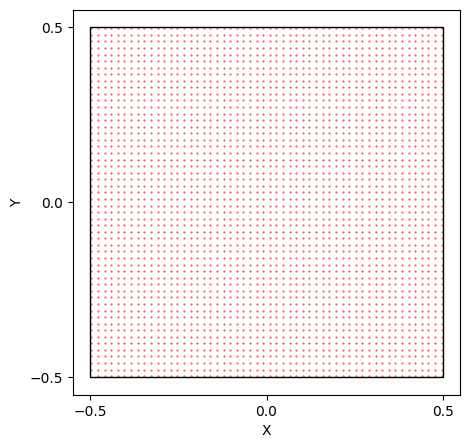

In [40]:
# Modes that should be tested, according to the task
TASK_MODES = {
    1: ("random", "same"),
    2: ("regular", "random"),
    3: ("regular", "same")
}

# Setting initial conditions
position, velocity = initial_conditions(*TASK_MODES[2])

# Basic statistics
N = position.shape[1]                   # Real number of particles
v_mean = np.abs(velocity).mean()        # Mean speed
v_MSR = np.sqrt(np.mean(velocity**2))   # MSR of velocity

print(f"N particles:\t{N}")
print(f"Mean speed:\t{v_mean:.3f}")
print(f"MSR of speed:\t{v_MSR:.3f}")

# Egor's criteria :D
mean_bias_per_step = dt * v_mean / R
print(f"Mean initial bias per epoch in R: {mean_bias_per_step:.3f}")

# Comparing indices for the each probable pair of particles
id_pairs = np.asarray(list(combinations(np.arange(N), 2)))

# === The initial distribution PIC ===
fig, ax = plt.subplots(1, 1, figsize=(5,5))
x, y = position[0][1:], position[1][1:]

ax.scatter(
    x, y, 
    c = 'red', 
    alpha = 1, 
    s = np.pi * (R * 210)**2    # s = area of marker in pt^2
)                               # scale factor 210 ~ okay, I think :D  

box_border = plt.Rectangle(
    xy = (-BOX_SIZE/2, -BOX_SIZE/2),
    width = BOX_SIZE,
    height=BOX_SIZE,
    fc = 'None',
    ec = 'Black',
    lw = 1
)
ax.add_patch(box_border)

ax.set_xlim(-1.1 * BOX_SIZE / 2, 1.1 * BOX_SIZE / 2)
ax.set_ylim(-1.1 * BOX_SIZE / 2, 1.1 * BOX_SIZE / 2)
ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)
ax.set_xlabel('X')
ax.set_ylabel('Y')

plt.show()

In [41]:
rs, vs, ball_colided_num, E = motion(position, velocity, T, dt, id_pairs)
ball_colided_num


Frames: 100%|██████████| 999/999 [01:33<00:00, 10.64Frame/s]


15685

MovieWriter Pillow unavailable; using Pillow instead.



Создание анимации...
Frame 1000/1000Анимация сохранена!


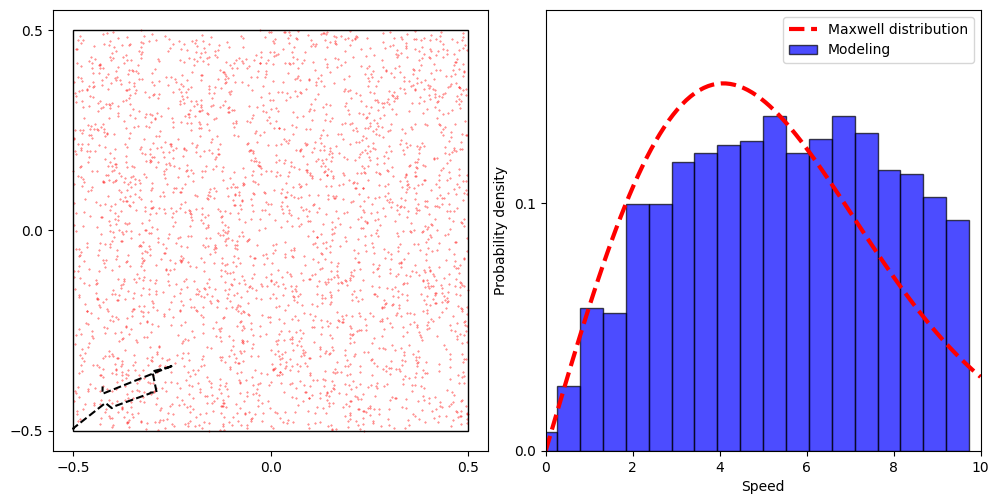

In [42]:
def get_module_vel_distribution(vs, i):
    return np.sqrt(vs[i][0]**2 + vs[i][1]**2)


fig, (ax, ax1) = plt.subplots(1, 2, figsize=(10, 5))
plt.tight_layout()  # один раз, не в цикле

# Данные для распределения Максвелла
speed_distr = np.linspace(0, 10, 100)
mean_E = v_MSR**2 / 2
distr = speed_distr / mean_E * np.exp(-speed_distr**2 / 2 / mean_E)

# Предварительно вычисляем все данные для всех кадров
num_frames = len(rs)
all_positions = [(rs[i][0], rs[i][1]) for i in range(num_frames)]
# Если get_module_vel_distribution можно векторизовать или предвычислить, делаем это:
all_v_mods = [get_module_vel_distribution(vs, i) for i in range(num_frames)]

# Инициализируем графики
# Частицы: scatter вместо множества Circle
scat = ax.scatter([], [], c='red', s=np.pi * (R * 210)**2, alpha=0.7)  # размер в пунктах
# Траектория
traj_line, = ax.plot([], [], color='black', linestyle='--', linewidth=1.5, label='Trajectory')

box_border = plt.Rectangle(
    xy     = (-BOX_SIZE / 2, -BOX_SIZE / 2),
    width  = BOX_SIZE,
    height = BOX_SIZE,
    fc = 'None',
    ec = 'Black',
    lw = 1
)
ax.add_patch(box_border)

ax.set_xlim(-1.1 * BOX_SIZE / 2, 1.1 * BOX_SIZE / 2)
ax.set_ylim(-1.1 * BOX_SIZE / 2, 1.1 * BOX_SIZE / 2)
ax.xaxis.set_major_locator(locator)
ax.yaxis.set_major_locator(locator)

# Гистограмма
bins = np.linspace(0, 10, 20)
# Создаём пустые столбцы
hist_bars = ax1.bar(bins[:-1], np.zeros(len(bins)-1), width=np.diff(bins),
                    color='blue', edgecolor='black', alpha=0.7, label='Modeling')
# Линия теории
theory_line, = ax1.plot(speed_distr, distr, '--', color='red', linewidth=3, label='Maxwell distribution')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 1.2*distr.max())
ax1.yaxis.set_major_locator(MultipleLocator(0.1))
ax1.set_xlabel('Speed')
ax1.set_ylabel('Probability density')
ax1.legend()

# Списки для траектории (будут накапливаться)
trajectory_x = []
trajectory_y = []

def init():
    """Инициализация фона (возвращаем все объекты, которые будут обновляться)"""
    scat.set_offsets(np.empty((0, 2)))
    traj_line.set_data([], [])
    for bar in hist_bars:
        bar.set_height(0)
    return scat, traj_line, *hist_bars, theory_line

def animate(i):
    x, y = all_positions[i]
    # Обновляем позиции частиц
    scat.set_offsets(np.c_[x, y])
    
    # Обновляем траекторию первой частицы
    trajectory_x.append(x[0])
    trajectory_y.append(y[0])
    traj_line.set_data(trajectory_x, trajectory_y)
    
    # Обновляем гистограмму
    v_mods = all_v_mods[i]
    hist_vals, _ = np.histogram(v_mods, bins=bins, density=True)
    for bar, h in zip(hist_bars, hist_vals):
        bar.set_height(h)
    
    # Прогресс
    sys.stdout.write(f"\rFrame {i+1}/{num_frames}")
    sys.stdout.flush()
    
    # Возвращаем все изменяемые объекты для blit
    return (scat, traj_line, *hist_bars, theory_line)

# Создаём анимацию с blit=True
ani = animation.FuncAnimation(fig, animate, frames=num_frames,
                              init_func=init, interval=33, repeat=False, blit=True)

# Сохраняем
print('\nСоздание анимации...')
ani.save('2d_gas_sim_rand_cords_v_one_vec.gif', writer="Pillow", fps=30)
print('Анимация сохранена!')

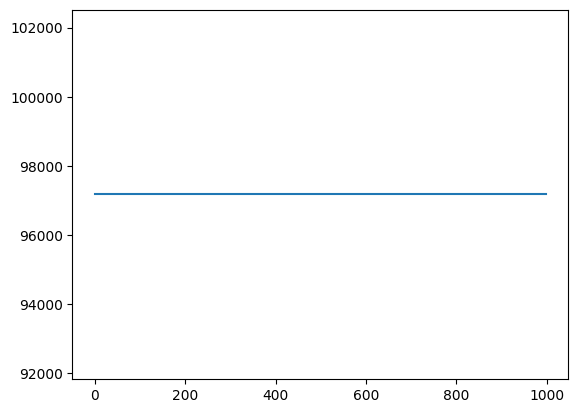

In [43]:
plt.plot(E)